<a href="https://colab.research.google.com/github/Kinghabib07/Booking-App/blob/master/Habib_Al_Wasil_Ulasan_Tempat_Cafe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install instaloader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 2.8 MB/s eta 0:00:00


In [ ]:
import instaloader
import pandas as pd
from datetime import datetime


SESSION_ID = "8482849865%3AAEoYUAI976xSMl%3A5%3AAYhvxZCm9BYwHG3GM20d9lp2R3eM7Mo_1fIJX9ZBzg"
MY_USER_AGENT = (
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/143.0.0.0 Safari/537.36"
)

L = instaloader.Instaloader(user_agent=MY_USER_AGENT)
L.context._session.cookies.set("sessionid", SESSION_ID)
L.context.username = "akun_presentasi"


POST_URL = "https://www.instagram.com/reel/CqAQ_SJJY6R/?utm_source=ig_web_copy_link"
shortcode = POST_URL.split("/reel/")[1].split("/")[0]

post = instaloader.Post.from_shortcode(L.context, shortcode)


data_comments = []

for comment in post.get_comments():
    data_comments.append({
        "username": comment.owner.username,
        "tanggal": comment.created_at_utc,
        "review": comment.text   # <-- PENTING (kolom teks utama)
    })


reviews = pd.DataFrame(data_comments)

print(f"[INFO] Total komentar berhasil diambil: {len(reviews)}")
reviews.head()

JSON Query to graphql/query: Expecting value: line 1 column 1 (char 0) [retrying; skip with ^C]


[INFO] Total komentar berhasil diambil: 145


,username,tanggal,review
0,anggasukapiscok,2025-10-15 16:23:37,@11.16ns ayuu kecinii hihi😁
1,imaniasyaa,2024-12-23 06:13:04,Min udah ada kolam renangnya??
2,keizio96,2023-06-15 02:42:36,cafe yg sebelm belokan tangkuban perahu bukan ya?
3,mayaputri2502,2023-06-14 09:05:16,@derrydarma49 sayangg😍
4,vhi2e,2023-06-13 10:53:11,Sdh ada kolam rendamnya y min...


t

In [ ]:
len(reviews.index)

145

Case Folding

In [ ]:
reviews['text_folded'] = reviews['review'].astype(str).str.lower()


print("Original data head:")
print(reviews[['review']].head()) # Display 'content' column for comparison
print("\nData after Case Folding:")
print(reviews[['text_folded']].head())

Original data head:
                                              review
0                        @11.16ns ayuu kecinii hihi😁
1                     Min udah ada kolam renangnya??
2  cafe yg sebelm belokan tangkuban perahu bukan ya?
3                             @derrydarma49 sayangg😍
4                   Sdh ada kolam rendamnya y min...

Data after Case Folding:
                                         text_folded
0                        @11.16ns ayuu kecinii hihi😁
1                     min udah ada kolam renangnya??
2  cafe yg sebelm belokan tangkuban perahu bukan ya?
3                             @derrydarma49 sayangg😍
4                   sdh ada kolam rendamnya y min...


Noise Removal (Cleansing)

In [ ]:
import re

def clean_text(text):
    # Pastikan data bertipe string (untuk menghindari error NaN)
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove numbers and punctuation (keep letters and spaces only)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Penerapan fungsi clean_text
reviews['cleaned_text'] = reviews['text_folded'].apply(clean_text)

print(reviews[['cleaned_text']].head())

                                       cleaned_text
0                              ns ayuu kecinii hihi
1                      min udah ada kolam renangnya
2  cafe yg sebelm belokan tangkuban perahu bukan ya
3                                           sayangg
4                     sdh ada kolam rendamnya y min


Slang Normalization

In [ ]:
# Kamus slang (Dalam prakteknya, ini bisa dibaca dari file .csv atau .json)
slang_dict = {
    "gw": "saya",
    "gtw": "tidak tahu",
    "mw": "mau",
    "kmn": "ke mana",
    "bsk": "besok",
    "gercep": "gerak cepat",
    "bro": "saudara",
    "jujurly": "sejujurnya",
    "ak": "aku",
    "cape": "lelah",
    "bgt": "sekali",
    "sm": "sama",
    "otw": "dalam perjalanan",
    "skrg": "sekarang",
    "gais": "teman-teman"
}

# Fungsi untuk melakukan normalisasi
def normalisasi_slang(text):
    # Memecah kalimat menjadi kata-kata
    words = text.split()
    # Mengganti kata jika ada di kamus
    normalized_words = [slang_dict.get(w.lower(), w) for w in words]
    # Menggabungkan kembali
    return ' '.join(normalized_words)

# Menerapkan fungsi ke kolom 'cleaned_text' di DataFrame 'reviews'
reviews['normalized_text'] = reviews['cleaned_text'].apply(normalisasi_slang)

# Menampilkan hasil
print("--- Hasil Pengolahan dengan Pandas (Slang Normalization) ---")
print(reviews[['cleaned_text', 'normalized_text']].head())

--- Hasil Pengolahan dengan Pandas (Slang Normalization) ---
                                       cleaned_text  \
0                              ns ayuu kecinii hihi   
1                      min udah ada kolam renangnya   
2  cafe yg sebelm belokan tangkuban perahu bukan ya   
3                                           sayangg   
4                     sdh ada kolam rendamnya y min   

                                    normalized_text  
0                              ns ayuu kecinii hihi  
1                      min udah ada kolam renangnya  
2  cafe yg sebelm belokan tangkuban perahu bukan ya  
3                                           sayangg  
4                     sdh ada kolam rendamnya y min  


Tokenizing

In [ ]:
# Fungsi untuk tokenisasi
def tokenize_text(text):
    return text.split()

# Menerapkan fungsi tokenisasi ke kolom 'normalized_text'
reviews['tokenized_text'] = reviews['normalized_text'].apply(tokenize_text)

print("\nHasil tokenizing per review:")
for i in range(min(10, len(reviews))):
    print(f"Review {i+1}:")
    print(reviews['tokenized_text'].iloc[i])
    print()


Hasil tokenizing per review:
Review 1:
['ns', 'ayuu', 'kecinii', 'hihi']

Review 2:
['min', 'udah', 'ada', 'kolam', 'renangnya']

Review 3:
['cafe', 'yg', 'sebelm', 'belokan', 'tangkuban', 'perahu', 'bukan', 'ya']

Review 4:
['sayangg']

Review 5:
['sdh', 'ada', 'kolam', 'rendamnya', 'y', 'min']

Review 6:
['subnag', 'nya', 'daerah', 'mana', 'kk']

Review 7:
['subang', 'utara', 'oh', 'subang', 'utara', 'seep', 'ku', 'tempat', 'wisata']

Review 8:
['muacetnyaaaa']

Review 9:
['deket', 'teu']

Review 10:
['tah', 'bergeser', 'ka', 'subang']



Stopword Removal menghapus kata" yang tidak relevan

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# mengambil kalimat dengan bahasa indonesia
list_stopwords = set(stopwords.words('indonesian'))

# Kalimat yang ga kedeteksi, bisa ditambahin kalimat informal atau istilah khusus
custom_stopwords = ['y','g','p','ap','yg', 'dg', 'kalo', 'udah', 'gak', 'nya', 'nih', 'juga', 'aja', 'bgt', 'tp', 'bisa', 'masuk', 'ini', 'ke']
list_stopwords.update(custom_stopwords)

print(f"Jumlah stopword: {len(list_stopwords)}")
print("Beberapa contoh stopword:\n", list(list_stopwords)[:40])

def remove_stopwords(tokens):
    return [word for word in tokens if word not in list_stopwords]

reviews['filtered_tokens'] = reviews['tokenized_text'].apply(remove_stopwords)

print("\nHasil stopword removal per review (pertama):")
for i in range(min(10, len(reviews))):
    print(f"Review {i+1}:")
    print(reviews['filtered_tokens'].iloc[i])
    print()

Jumlah stopword: 772
Beberapa contoh stopword:
 ['semuanya', 'dimaksudkan', 'sedemikian', 'bagaikan', 'ia', 'berawal', 'sayalah', 'walau', 'tentunya', 'udah', 'dituturkan', 'menunjukkan', 'naik', 'terbanyak', 'kepadanya', 'perlu', 'ataukah', 'terus', 'diucapkan', 'perlunya', 'menanyai', 'merasa', 'akhiri', 'ibaratnya', 'termasuk', 'sebuah', 'selalu', 'sebagaimana', 'tiba-tiba', 'mengira', 'diberikannya', 'semisalnya', 'semasih', 'sekalian', 'cuma', 'justru', 'siap', 'sekali', 'dilihat', 'walaupun']

Hasil stopword removal per review (pertama):
Review 1:
['ns', 'ayuu', 'kecinii', 'hihi']

Review 2:
['min', 'kolam', 'renangnya']

Review 3:
['cafe', 'sebelm', 'belokan', 'tangkuban', 'perahu', 'ya']

Review 4:
['sayangg']

Review 5:
['sdh', 'kolam', 'rendamnya', 'min']

Review 6:
['subnag', 'daerah', 'kk']

Review 7:
['subang', 'utara', 'oh', 'subang', 'utara', 'seep', 'ku', 'wisata']

Review 8:
['muacetnyaaaa']

Review 9:
['deket', 'teu']

Review 10:
['tah', 'bergeser', 'ka', 'subang']



temming & Lemmatzaation

In [ ]:
!pip install Sastrawi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.1 MB/s eta 0:00:00


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


In [ ]:
# Membuat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()


In [ ]:
def stemming_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]


In [ ]:
reviews['stemmed_tokens'] = reviews['filtered_tokens'].apply(stemming_tokens)


In [ ]:
print("\nHasil Stemming per review (contoh):")
for i in range(min(10, len(reviews))):
    print(f"Review {i+1}:")
    print("Sebelum :", reviews['filtered_tokens'].iloc[i])
    print("Sesudah :", reviews['stemmed_tokens'].iloc[i])
    print()



Hasil Stemming per review (contoh):
Review 1:
Sebelum : ['ns', 'ayuu', 'kecinii', 'hihi']
Sesudah : ['ns', 'ayuu', 'kecinii', 'hihi']

Review 2:
Sebelum : ['min', 'kolam', 'renangnya']
Sesudah : ['min', 'kolam', 'renang']

Review 3:
Sebelum : ['cafe', 'sebelm', 'belokan', 'tangkuban', 'perahu', 'ya']
Sesudah : ['cafe', 'sebelm', 'belok', 'tangkuban', 'perahu', 'ya']

Review 4:
Sebelum : ['sayangg']
Sesudah : ['sayangg']

Review 5:
Sebelum : ['sdh', 'kolam', 'rendamnya', 'min']
Sesudah : ['sdh', 'kolam', 'rendam', 'min']

Review 6:
Sebelum : ['subnag', 'daerah', 'kk']
Sesudah : ['subnag', 'daerah', 'kk']

Review 7:
Sebelum : ['subang', 'utara', 'oh', 'subang', 'utara', 'seep', 'ku', 'wisata']
Sesudah : ['subang', 'utara', 'oh', 'subang', 'utara', 'seep', 'ku', 'wisata']

Review 8:
Sebelum : ['muacetnyaaaa']
Sesudah : ['muacetnyaaaa']

Review 9:
Sebelum : ['deket', 'teu']
Sesudah : ['deket', 'teu']

Review 10:
Sebelum : ['tah', 'bergeser', 'ka', 'subang']
Sesudah : ['tah', 'geser', 'ka'

apply ke data

In [ ]:
reviews['final_text'] = reviews['stemmed_tokens'].apply(lambda x: ' '.join(x))

print("\nFinal text setelah stemming:")
print(reviews[['final_text']].head())



Final text setelah stemming:
                              final_text
0                   ns ayuu kecinii hihi
1                       min kolam renang
2  cafe sebelm belok tangkuban perahu ya
3                                sayangg
4                   sdh kolam rendam min


TF IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8
)


In [ ]:
X_tfidf = tfidf.fit_transform(reviews['final_text'])


In [ ]:
print("Shape TF-IDF:", X_tfidf.shape)


Shape TF-IDF: (145, 8)


In [ ]:
feature_names = tfidf.get_feature_names_out()
print("Contoh fitur TF-IDF:", feature_names[:20])


Contoh fitur TF-IDF: ['bagus' 'deket' 'kesini' 'kolam' 'min' 'subang' 'wisata' 'ya']


SENTIMEN ANALISIS


VADER

In [ ]:
!pip install vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.1 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [ ]:
vader = SentimentIntensityAnalyzer()


In [ ]:
def vader_sentiment(text):
    score = vader.polarity_scores(text)
    return score


In [ ]:
reviews['vader_score'] = reviews['final_text'].apply(vader_sentiment)


In [ ]:
reviews['vader_compound'] = reviews['vader_score'].apply(lambda x: x['compound'])


In [ ]:
def vader_label(compound):
    if compound >= 0.05:
        return 'positif'
    elif compound <= -0.05:
        return 'negatif'
    else:
        return 'netral'

reviews['vader_sentiment'] = reviews['vader_compound'].apply(vader_label)


In [ ]:
#vader
reviews[['final_text', 'vader_compound', 'vader_sentiment']].head()


,final_text,vader_compound,vader_sentiment
0,ns ayuu kecinii hihi,0.0,netral
1,min kolam renang,0.0,netral
2,cafe sebelm belok tangkuban perahu ya,0.0,netral
3,sayangg,0.0,netral
4,sdh kolam rendam min,0.0,netral


In [ ]:
sentiment_count = reviews['vader_sentiment'].value_counts()
print(sentiment_count)


vader_sentiment
netral     141
positif      4
Name: count, dtype: int64


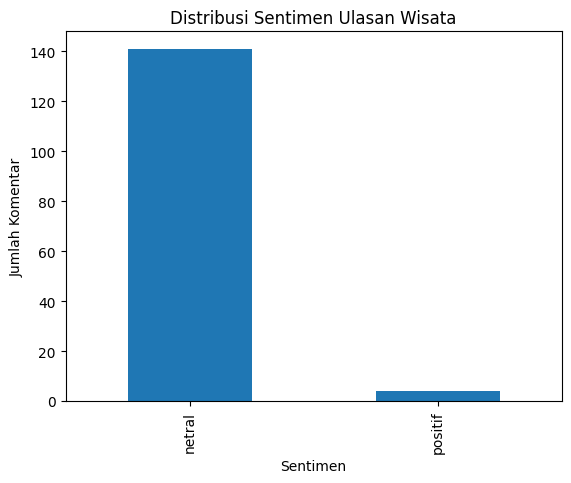

In [ ]:
import matplotlib.pyplot as plt

sentiment_count = reviews['vader_sentiment'].value_counts()

sentiment_count.plot(kind='bar')
plt.title('Distribusi Sentimen Ulasan Wisata')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Komentar')
plt.show()


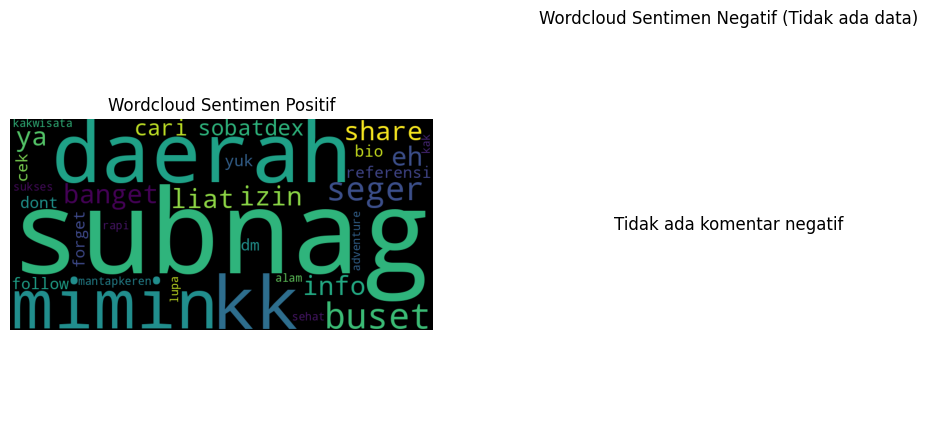

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = ' '.join(
    reviews[reviews['vader_sentiment']=='positif']['final_text']
)
negative_text = ' '.join(
    reviews[reviews['vader_sentiment']=='negatif']['final_text']
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
if positive_text:
    wc_pos = WordCloud(width=800, height=400).generate(positive_text)
    plt.imshow(wc_pos)
    plt.title('Wordcloud Sentimen Positif')
else:
    plt.text(0.5, 0.5, 'Tidak ada komentar positif', horizontalalignment='center', verticalalignment='center', fontsize=12)
    plt.title('Wordcloud Sentimen Positif (Tidak ada data)')
plt.axis('off')


plt.subplot(1,2,2)
if negative_text:
    wc_neg = WordCloud(width=800, height=400).generate(negative_text)
    plt.imshow(wc_neg)
    plt.title('Wordcloud Sentimen Negatif')
else:
    plt.text(0.5, 0.5, 'Tidak ada komentar negatif', horizontalalignment='center', verticalalignment='center', fontsize=12)
    plt.title('Wordcloud Sentimen Negatif (Tidak ada data)')
plt.axis('off')

plt.show()

LDA

In [ ]:
!pip install gensim pyLDAvis


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 87.7 MB/s eta 0:00:00


In [ ]:
import gensim
from gensim import corpora


In [ ]:
# Ambil token hasil preprocessing
texts = reviews['stemmed_tokens'].tolist()


In [ ]:
dictionary = corpora.Dictionary(texts)

# Filter kata yang terlalu jarang / terlalu sering
dictionary.filter_extremes(no_below=10, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in texts]


In [ ]:
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=10,
    alpha='auto'
)


In [ ]:
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topik {idx+1}: {topic}")


Topik 1: 0.513*"ya" + 0.487*"subang"
Topik 2: 0.975*"subang" + 0.025*"ya"
Topik 3: 0.963*"ya" + 0.037*"subang"


In [ ]:
def dominant_topic(lda_model, corpus):
    dominant_topics = []
    for doc in corpus:
        topics = lda_model.get_document_topics(doc)
        dominant = max(topics, key=lambda x: x[1])[0]
        dominant_topics.append(dominant)
    return dominant_topics

reviews['dominant_topic'] = dominant_topic(lda_model, corpus)


In [ ]:
reviews[['final_text', 'dominant_topic']].head()


,final_text,dominant_topic
0,ns ayuu kecinii hihi,2
1,min kolam renang,2
2,cafe sebelm belok tangkuban perahu ya,2
3,sayangg,2
4,sdh kolam rendam min,2


In [ ]:
pd.crosstab(
    reviews['dominant_topic'],
    reviews['vader_sentiment']
)


vader_sentiment,netral,positif
dominant_topic,,
1,10,0
2,131,4


In [ ]:
positive_topics = reviews[reviews['vader_sentiment'] == 'positif']['dominant_topic'].value_counts()
print("Topik pada sentimen positif:")
print(positive_topics)


Topik pada sentimen positif:
dominant_topic
2    4
Name: count, dtype: int64


In [ ]:
neutral_topics = reviews[reviews['vader_sentiment'] == 'netral']['dominant_topic'].value_counts()
print("Topik pada sentimen netral:")
print(neutral_topics)


Topik pada sentimen netral:
dominant_topic
2    131
1     10
Name: count, dtype: int64


In [ ]:
negative_topics = reviews[reviews['vader_sentiment'] == 'negatif']['dominant_topic'].value_counts()
print("Topik pada sentimen negatif:")
print(negative_topics)


Topik pada sentimen negatif:
Series([], Name: count, dtype: int64)


In [ ]:
from collections import Counter

def dominant_words(df, sentiment, top_n=10):
    tokens = df[df['vader_sentiment'] == sentiment]['stemmed_tokens']
    all_words = [word for sublist in tokens for word in sublist]
    return Counter(all_words).most_common(top_n)


In [ ]:
print("Kata dominan - Positif:")
print(dominant_words(reviews, 'positif'))

print("\nKata dominan - Netral:")
print(dominant_words(reviews, 'netral'))

print("\nKata dominan - Negatif:")
print(dominant_words(reviews, 'negatif'))


Kata dominan - Positif:
[('subnag', 2), ('daerah', 2), ('kk', 2), ('mimin', 2), ('buset', 1), ('seger', 1), ('banget', 1), ('liat', 1), ('eh', 1), ('izin', 1)]

Kata dominan - Netral:
[('subang', 14), ('ya', 11), ('min', 8), ('kolam', 6), ('wisata', 6), ('bagus', 6), ('deket', 5), ('teh', 5), ('kesini', 5), ('utara', 4)]

Kata dominan - Negatif:
[]


In [ ]:
reviews.to_csv(
    "hasil_analisis_lengkap.csv",
    index=False,
    encoding="utf-8-sig"
)

print("[INFO] Dataset lengkap berhasil disimpan (hasil_analisis_lengkap.csv)")

[INFO] Dataset lengkap berhasil disimpan (hasil_analisis_lengkap.csv)


In [ ]:
reviews[['review', 'vader_sentiment', 'dominant_topic']].head(10)


,review,vader_sentiment,dominant_topic
0,@11.16ns ayuu kecinii hihi😁,netral,2
1,Min udah ada kolam renangnya??,netral,2
2,cafe yg sebelm belokan tangkuban perahu bukan ya?,netral,2
3,@derrydarma49 sayangg😍,netral,2
4,Sdh ada kolam rendamnya y min...,netral,2
5,Subnag nya daerah mana kk,positif,2
6,subang utara oh subang utara.. seep ku tempat ...,netral,1
7,Muacetnyaaaa…. 😫😫,netral,2
8,Deket teu @rizki_fajar_iki,netral,2
9,@winaw.19 @rismaanur__ tah bergeser ka Subang,netral,1


In [ ]:
reviews[reviews['vader_sentiment']=='negatif']['review'].head(3)


,review
